In [4]:
from scipy.stats import wasserstein_distance, gaussian_kde
from co_evolution_modified import opinion_dynamics
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os

In [ ]:
opinion_data = pd.read_csv("../data/mock_data.csv", parse_dates=['Day'], index_col="Day")
print(opinion_data.iloc[0])

-2    0.013
-1    0.353
0     0.446
1     0.174
2     0.014
Name: 2021-05-20 00:00:00, dtype: float64


In [46]:
data = pd.read_csv(os.path.join('data', 'merged_covid_and_opinion_data.csv'), parse_dates=['Day'], index_col='Day')
idx = data.index[data.notna().all(axis=1)]
new_cases = data['daily-new-confirmed-covid-19-cases-per-million-people'].rolling(window=7).mean()
new_cases = new_cases.loc[idx]
new_cases.name = "Cases"

In [ ]:
new_df = opinion_data.join(new_cases, on="Day")
new_df.to_csv("mock_data_with_cases.csv")

<Axes: xlabel='Day'>

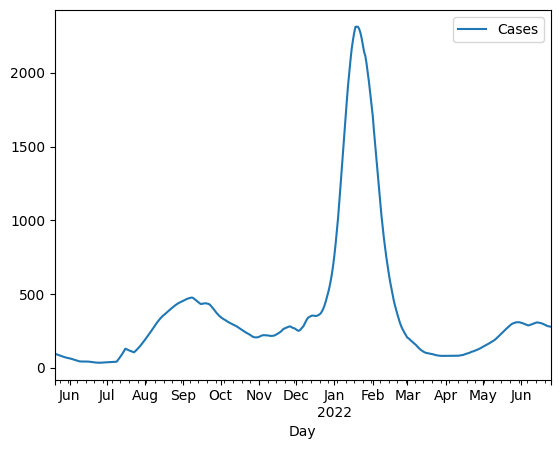

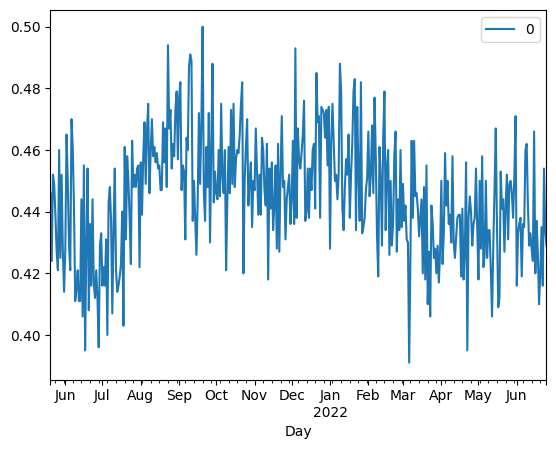

In [57]:
new_df.plot(y="Cases")
new_df.plot(y="0")